# Exercise 6: Fine-Tuning an LLM for Pharmacology (QLoRA)

## Environment Setup

In [ ]:
# ## 1.1) Import Libraries and Set Deterministic Seed
import os
import json
import math
import random
import subprocess
from datetime import datetime
import pathlib

import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import LoraConfig, prepare_model_for_kbit_training

# Windows/locale workaround:
# TRL reads template files with the default system encoding.
# On some Windows setups this is cp1252 and can fail.
_original_read_text = pathlib.Path.read_text

def _read_text_utf8(self, encoding=None, errors=None, newline=None):
    return _original_read_text(
        self,
        encoding=(encoding or "utf-8"),
        errors=errors,
        newline=newline,
    )

pathlib.Path.read_text = _read_text_utf8

from trl.trainer.sft_trainer import SFTTrainer
from trl.trainer.sft_config import SFTConfig

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ## 1.2) Define Fine-Tuning Configuration
# -------------------------------
# Core project configuration
# -------------------------------
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_ID = "shishir1807/phi_drug"
OUTPUT_DIR = "./outputs_pharma_qlora"
ADAPTER_DIR = f"{OUTPUT_DIR}/adapter"
LOG_DIR = f"{OUTPUT_DIR}/logs"
BASELINE_OUTPUT_PATH = f"{OUTPUT_DIR}/baseline_generations.json"
AFTER_OUTPUT_PATH = f"{OUTPUT_DIR}/finetuned_generations.json"
TRAIN_REPORT_PATH = f"{OUTPUT_DIR}/training_report.json"

# -------------------------------
# Data + sequence settings
# -------------------------------
MAX_SEQ_LENGTH = 512
TEST_SIZE = 0.1

# -------------------------------
# QLoRA / training settings (RTX 4050 6GB friendly)
# -------------------------------
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 1
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# -------------------------------
# Safe dry-run mode
# -------------------------------
DRY_RUN = True
MAX_TRAIN_SAMPLES_DRY = 48
MAX_EVAL_SAMPLES_DRY = 12
SAFE_DRY_RUN_STEPS = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Config ready.")
print(json.dumps({
    "model": MODEL_ID,
    "dataset": DATASET_ID,
    "dry_run": DRY_RUN,
    "safe_dry_run_steps": SAFE_DRY_RUN_STEPS,
    "epochs": NUM_EPOCHS,
    "lora_rank": LORA_RANK,
    "max_seq_length": MAX_SEQ_LENGTH,
}, indent=2))

Config ready.
{
  "model": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
  "dataset": "shishir1807/phi_drug",
  "dry_run": true,
  "safe_dry_run_steps": 2,
  "epochs": 1,
  "lora_rank": 16,
  "max_seq_length": 512
}


In [ ]:
# ## 1.3) Validate Hardware and Save Environment Report
def gpu_report():
    report = {}
    report["cuda_available"] = torch.cuda.is_available()
    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        report["total_vram_gb"] = round(props.total_memory / (1024 ** 3), 2)
        report["cuda_version_torch"] = torch.version.cuda

    try:
        smi = subprocess.check_output(["nvidia-smi"], text=True)
        report["nvidia_smi"] = smi[:2500]
    except Exception as exc:
        report["nvidia_smi"] = f"nvidia-smi unavailable: {exc}"

    return report

env_info = gpu_report()
print(json.dumps(env_info, indent=2))

with open(f"{LOG_DIR}/environment_report.json", "w", encoding="utf-8") as f:
    json.dump(env_info, f, indent=2)

print("Saved environment report.")

{
  "cuda_available": false,
  "nvidia_smi": "Fri Apr 24 23:26:04 2026       \n+-----------------------------------------------------------------------------------------+\n| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |\n+-----------------------------------------+------------------------+----------------------+\n| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |\n| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |\n|                                         |                        |               MIG M. |\n|=========================================+========================+======================|\n|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |\n| N/A   41C    P8              1W /   65W |      81MiB /   6141MiB |      0%      Default |\n|                                         |                        |                

## Dataset Loading and Instruction Formatting.

In [5]:
# ## 2.1) Load Domain Dataset
dataset_dict = load_dataset(DATASET_ID)

if "train" in dataset_dict:
    raw_ds = dataset_dict["train"]
else:
    first_split = list(dataset_dict.keys())[0]
    raw_ds = dataset_dict[first_split]

print(f"Loaded dataset: {DATASET_ID}")
print(f"Rows: {len(raw_ds)}")
print(f"Columns: {raw_ds.column_names}")
print("\nSample row:")
print(raw_ds[0])

Loaded dataset: shishir1807/phi_drug
Rows: 53428
Columns: ['id', 'instruction', 'input', 'output', 'text']

Sample row:
{'id': 20940, 'instruction': 'Identify all the mentioned drugs in the given text. Text may or may not contain drug. If they contain more than 1 drug, use ";" as delimiter and join them.', 'input': '1-002 - T2 Lesion Burden Modifies The Association Between Serum Neurofilament And Clinical Outcomes In MS PATHS (Partners Advancing Technology And Health Solutions)', 'output': None, 'text': 'Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request. ### Instruction: Identify all the mentioned drugs in the given text. Text may or may not contain drug. If they contain more than 1 drug, use ";" as delimiter and join them. ### Input: 1-002 - T2 Lesion Burden Modifies The Association Between Serum Neurofilament And Clinical Outcomes In MS PATHS (Partners Advancing Technology And H

In [ ]:
# System behavior used in every training example
SYSTEM_PROMPT = (
    "You are a pharmacology assistant. Provide clear, structured, educational information "
    "and include a safety note when relevant. Do not provide personalized medical advice."
)

# Single template used for medicine questions in training/inference.
# Edit this one line to quickly change prompt style.
USER_PROMPT_TEMPLATE = "Provide information on the medicine {drug_name}."

# Helper: pick the first non-empty value from possible column names
def pick_value(row, candidates):
    for key in candidates:
        if key in row and row[key] is not None:
            value = str(row[key]).strip()
            if value:
                return value
    return ""

# Convert one raw dataset row into a clean instruction/response pair
def row_to_instruction_response(row):
    drug_name = pick_value(row, ["drug_name", "drug", "name", "medicine", "generic_name", "title"])
    mechanism = pick_value(row, ["mechanism", "mechanism_of_action", "moa", "action"])
    indications = pick_value(row, ["indications", "uses", "use", "therapeutic_use"])
    side_effects = pick_value(row, ["side_effects", "adverse_effects", "adverse_reactions", "warnings"])
    contraindications = pick_value(row, ["contraindications", "contraindication", "precautions"])
    interactions = pick_value(row, ["interactions", "drug_interactions"])
    dosage = pick_value(row, ["dosage", "dose", "administration"])

    if not drug_name:
        drug_name = pick_value(row, ["instruction", "question", "prompt", "query"]) or "Unknown medicine"

    instruction = USER_PROMPT_TEMPLATE.format(drug_name=drug_name)

    sections = []
    if mechanism:
        sections.append(f"Mechanism of Action: {mechanism}")
    if indications:
        sections.append(f"Indications: {indications}")
    if side_effects:
        sections.append(f"Side Effects: {side_effects}")
    if contraindications:
        sections.append(f"Contraindications: {contraindications}")
    if interactions:
        sections.append(f"Drug Interactions: {interactions}")
    if dosage:
        sections.append(f"Dosage/Administration: {dosage}")

    fallback_answer = pick_value(row, ["response", "answer", "output", "description", "text"])
    if not sections and fallback_answer:
        sections.append(f"Clinical Summary: {fallback_answer}")
    if not sections:
        sections.append("Clinical Summary: No additional structured details available in source record.")

    sections.append("Safety Note: This information is for education only and does not replace professional medical advice.")
    response = "\n".join(sections)

    return {"instruction": instruction, "response": response, "drug_name": drug_name}

# Build final text using chat-template format (fallback included)
def safe_chat_format(tokenizer, system_text, instruction_text, response_text):
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": instruction_text},
        {"role": "assistant", "content": response_text},
    ]
    try:
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    except Exception:
        return (
            f"<|system|>\n{system_text}\n"
            f"<|user|>\n{instruction_text}\n"
            f"<|assistant|>\n{response_text}"
        )

In [7]:
# ## 2.3) Tokenize and Build Train/Eval Splits
# Tokenizer is needed now for chat-template formatting.
# HF token is optional for public models and required for gated/private models.
from huggingface_hub import get_token

HF_TOKEN = os.environ.get("HF_TOKEN") or get_token()
model_auth_kwargs = {"token": HF_TOKEN} if HF_TOKEN else {}

if HF_TOKEN:
    print("Hugging Face auth token detected.")
else:
    print("No HF token found. Continuing with public model access.")

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, **model_auth_kwargs)
except Exception as exc:
    raise RuntimeError(
        f"Cannot load tokenizer for {MODEL_ID}. If the model is gated/private, log in with `hf auth login`.\n{exc}"
    )

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def format_row(row):
    obj = row_to_instruction_response(row)
    text = safe_chat_format(tokenizer, SYSTEM_PROMPT, obj["instruction"], obj["response"])
    return {
        "drug_name": obj["drug_name"],
        "instruction": obj["instruction"],
        "response": obj["response"],
        "text": text,
    }

formatted_ds = raw_ds.map(format_row)
split_ds = formatted_ds.train_test_split(test_size=TEST_SIZE, seed=SEED)
train_ds = split_ds["train"]
eval_ds = split_ds["test"]

if DRY_RUN:
    train_ds = train_ds.select(range(min(MAX_TRAIN_SAMPLES_DRY, len(train_ds))))
    eval_ds = eval_ds.select(range(min(MAX_EVAL_SAMPLES_DRY, len(eval_ds))))

print(f"Model used: {MODEL_ID}")
print(f"Train size: {len(train_ds)}")
print(f"Eval size:  {len(eval_ds)}")

Hugging Face auth token detected.
Model used: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Train size: 48
Eval size:  12


In [8]:
# ## 2.4) Preview a Formatted Training Sample
sample_idx = 0
print("Instruction sample:\n")
print(train_ds[sample_idx]["instruction"])
print("\nResponse sample:\n")
print(train_ds[sample_idx]["response"])
print("\nSerialized training text sample (truncated):\n")
print(train_ds[sample_idx]["text"][:1200])

Instruction sample:

Provide information on the medicine Identify all the mentioned drugs in the given text. Text may or may not contain drug. If they contain more than 1 drug, use ";" as delimiter and join them..

Response sample:

Clinical Summary: AZD5305;Ceralasertib
Safety Note: This information is for education only and does not replace professional medical advice.

Serialized training text sample (truncated):

<|system|>
You are a pharmacology assistant. Provide clear, structured, educational information and include a safety note when relevant. Do not provide personalized medical advice.</s>
<|user|>
Provide information on the medicine Identify all the mentioned drugs in the given text. Text may or may not contain drug. If they contain more than 1 drug, use ";" as delimiter and join them..</s>
<|assistant|>
Clinical Summary: AZD5305;Ceralasertib
Safety Note: This information is for education only and does not replace professional medical advice.</s>



## QLoRA Model Setup and Fine-Tuning

In [9]:
# ## 3.1) Load Base Model and Configure LoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# Use 4-bit quantization on CUDA. On CPU, load without quantization.
if torch.cuda.is_available():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        **model_auth_kwargs,
    )
else:
    print("CUDA unavailable. Loading model on CPU without quantization.")
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map="cpu",
        torch_dtype=torch.float32,
        **model_auth_kwargs,
    )

model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

print(f"Model and LoRA config ready for: {MODEL_ID}")

CUDA unavailable. Loading model on CPU without quantization.


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and LoRA config ready for: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [10]:
def build_inference_prompt(drug_name, system_prompt=None, user_prompt_template=None):
    active_system_prompt = (system_prompt or SYSTEM_PROMPT).strip()
    template = (user_prompt_template or USER_PROMPT_TEMPLATE).strip()
    if "{drug_name}" not in template:
        template = template + " {drug_name}"
    user_prompt = template.format(drug_name=drug_name)

    messages = [
        {"role": "system", "content": active_system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        return (
            f"<|system|>\n{active_system_prompt}\n"
            f"<|user|>\n{user_prompt}\n"
            f"<|assistant|>\n"
        )


def _resolve_model_device(current_model):
    try:
        return next(current_model.parameters()).device
    except Exception:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_answer(
    current_model,
    drug_name,
    max_new_tokens=220,
    temperature=0.2,
    system_prompt=None,
    user_prompt_template=None,
):
    prompt = build_inference_prompt(
        drug_name,
        system_prompt=system_prompt,
        user_prompt_template=user_prompt_template,
    )
    device = _resolve_model_device(current_model)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = current_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

In [11]:
# ## 3.3) Baseline Generation (Before Fine-Tuning)
baseline_prompts = ["Metformin"] if DRY_RUN else ["Metformin", "Warfarin", "Amoxicillin"]

baseline_outputs = {}
for drug in baseline_prompts:
    baseline_outputs[drug] = generate_answer(model, drug)

with open(BASELINE_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(baseline_outputs, f, indent=2, ensure_ascii=False)

baseline_df = pd.DataFrame([
    {"drug": k, "before_finetune_output": v} for k, v in baseline_outputs.items()
])
print("Saved baseline generations.")
display(baseline_df)

[transformers] Both `max_new_tokens` (=220) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Saved baseline generations.


,drug,before_finetune_output
0,Metformin,Metformin is an oral medication used to treat ...


In [12]:
# ## 3.4) Initialize SFT Trainer
# Train in a very safe low-step mode when DRY_RUN=True
fp16_enabled = torch.cuda.is_available()
max_steps = SAFE_DRY_RUN_STEPS if DRY_RUN else -1
eval_steps = 2 if DRY_RUN else 25
save_steps = 2 if DRY_RUN else 25

if DRY_RUN and not torch.cuda.is_available():
    # Keep CPU dry-run very short.
    train_ds = train_ds.select(range(min(16, len(train_ds))))
    eval_ds = eval_ds.select(range(min(8, len(eval_ds))))

# bitsandbytes optimizer needs compatible CUDA. Use torch optimizer on CPU.
optimizer_name = "paged_adamw_32bit" if torch.cuda.is_available() else "adamw_torch"

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    num_train_epochs=NUM_EPOCHS,
    max_steps=max_steps,
    logging_steps=1,
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=save_steps,
    optim=optimizer_name,
    fp16=fp16_enabled,
    bf16=False,
    gradient_checkpointing=True,
    max_grad_norm=0.3,
    warmup_steps=0,
    report_to="none",
    load_best_model_at_end=False,
    seed=SEED,
    dataset_text_field="text",
    max_length=MAX_SEQ_LENGTH,
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
    peft_config=lora_config,
)

print("Trainer initialized.")
print(
    f"Model={MODEL_ID} | DRY_RUN={DRY_RUN} | max_steps={max_steps} | "
    f"eval_steps={eval_steps} | save_steps={save_steps} | optim={optimizer_name}"
)

Trainer initialized.
Model=TinyLlama/TinyLlama-1.1B-Chat-v1.0 | DRY_RUN=True | max_steps=2 | eval_steps=2 | save_steps=2 | optim=adamw_torch


In [13]:
# ## 3.5) Train, Evaluate, and Save Adapter
train_result = trainer.train()
eval_metrics = trainer.evaluate()

active_trained_model = getattr(trainer, "model", None)
if active_trained_model is None:
    raise RuntimeError("Trained model is unavailable after training.")
active_trained_model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

eval_loss_value = float(eval_metrics.get("eval_loss", 0.0))
perplexity_value = float(math.exp(eval_loss_value)) if eval_loss_value > 0 else float("nan")

runtime_report = {
    "train_runtime_seconds": float(train_result.metrics.get("train_runtime", 0.0)),
    "train_samples_per_second": float(train_result.metrics.get("train_samples_per_second", 0.0)),
    "final_eval_loss": eval_loss_value,
    "final_eval_perplexity": perplexity_value,
}

with open(TRAIN_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(runtime_report, f, indent=2)

print("Training complete.")
print(json.dumps(runtime_report, indent=2))

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.
c:\Users\USER\Codes\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss
2,2.527625,2.273905


c:\Users\USER\Codes\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step
2.527625,2.273905,2


Training complete.
{
  "train_runtime_seconds": 97.6599,
  "train_samples_per_second": 0.164,
  "final_eval_loss": 2.273905038833618,
  "final_eval_perplexity": 9.717273148478945
}


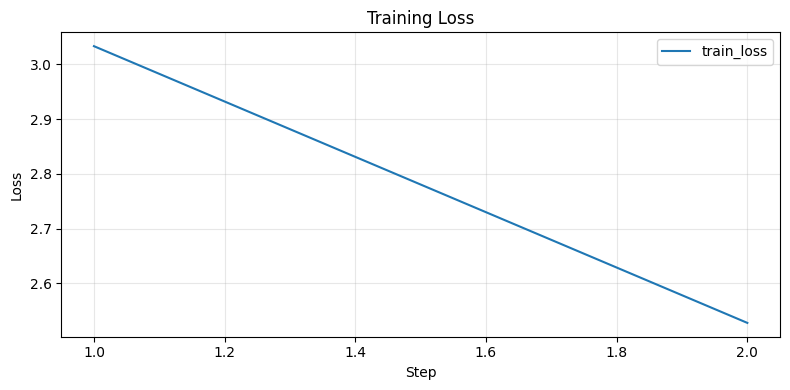

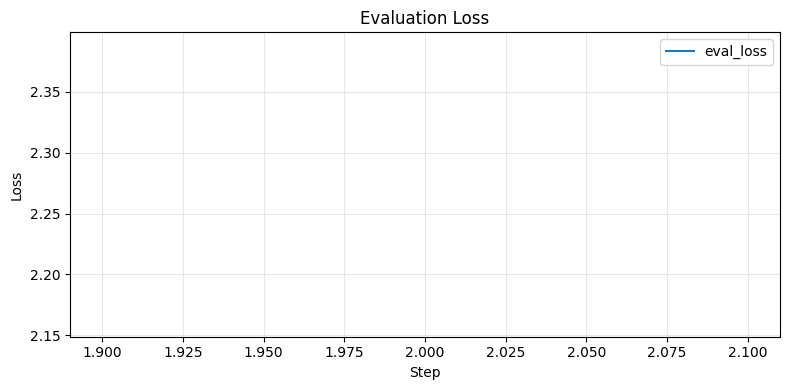

In [31]:
# ## 3.6) Visualize Training and Evaluation Loss Curves
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(f"{LOG_DIR}/trainer_log_history.csv", index=False)

if "loss" in log_df.columns:
    plt.figure(figsize=(8, 4))
    plot_df = log_df.dropna(subset=["loss"])
    plt.plot(plot_df["step"], plot_df["loss"], label="train_loss")
    plt.title("Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if "eval_loss" in log_df.columns:
    plt.figure(figsize=(8, 4))
    plot_df = log_df.dropna(subset=["eval_loss"])
    plt.plot(plot_df["step"], plot_df["eval_loss"], label="eval_loss")
    plt.title("Evaluation Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Evaluation: Before vs After Fine-Tuning

In [15]:
# ## 4.1) Post-Fine-Tuning Generation
fine_tuned_model = getattr(trainer, "model", None)
if fine_tuned_model is None:
    raise RuntimeError("Fine-tuned model is unavailable. Run the training cell before evaluation.")
fine_tuned_model.eval()

after_outputs = {}
for drug in baseline_prompts:
    after_outputs[drug] = generate_answer(fine_tuned_model, drug)

with open(AFTER_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(after_outputs, f, indent=2, ensure_ascii=False)

after_df = pd.DataFrame([
    {"drug": k, "after_finetune_output": v} for k, v in after_outputs.items()
])
print("Saved post-finetune generations.")
display(after_df)

[transformers] Both `max_new_tokens` (=220) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Saved post-finetune generations.


,drug,after_finetune_output
0,Metformin,Metformin is an oral medication used to treat ...


,drug,before_structure_hits,after_structure_hits,total_possible,before_chars,after_chars,before_preview,after_preview
0,Metformin,2,3,5,684,749,Metformin is an oral medication used to treat ...,Metformin is an oral medication used to treat ...


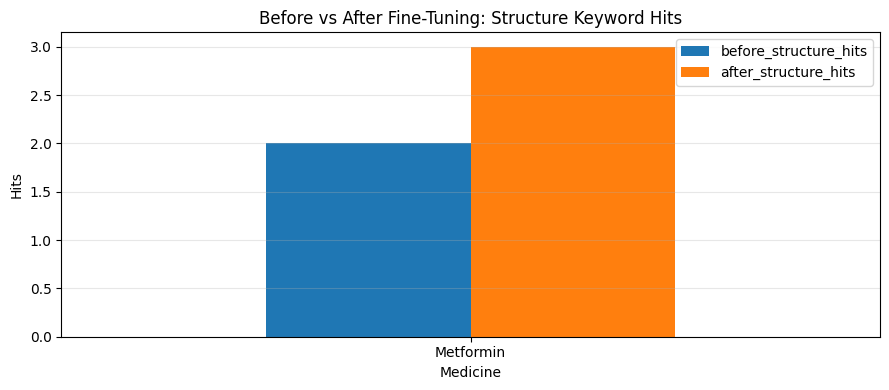

In [16]:
# ## 4.2) Structured Quality Comparison and Visualization
def structure_score(text):
    lowered = text.lower()
    keywords = [
        "mechanism",
        "indications",
        "side effects",
        "contraindications",
        "safety note",
    ]
    hits = sum(1 for kw in keywords if kw in lowered)
    return hits, len(keywords)

rows = []
for drug in baseline_prompts:
    before = baseline_outputs.get(drug, "")
    after = after_outputs.get(drug, "")
    b_hits, total = structure_score(before)
    a_hits, _ = structure_score(after)

    rows.append({
        "drug": drug,
        "before_structure_hits": b_hits,
        "after_structure_hits": a_hits,
        "total_possible": total,
        "before_chars": len(before),
        "after_chars": len(after),
        "before_preview": before[:180],
        "after_preview": after[:180],
    })

compare_df = pd.DataFrame(rows)
display(compare_df)

plot_df = compare_df[["drug", "before_structure_hits", "after_structure_hits"]].set_index("drug")
ax = plot_df.plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_title("Before vs After Fine-Tuning: Structure Keyword Hits")
ax.set_xlabel("Medicine")
ax.set_ylabel("Hits")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# ## 4.3) Detailed Before/After Preview
from html import escape
from IPython.display import HTML

PREVIEW_CHARS = 1400 if DRY_RUN else 900

detailed_rows = []
for drug in baseline_prompts:
    before_text = baseline_outputs.get(drug, "")
    after_text = after_outputs.get(drug, "")
    before_hits, total_hits = structure_score(before_text)
    after_hits, _ = structure_score(after_text)

    detailed_rows.append({
        "drug": drug,
        "before_chars": len(before_text),
        "after_chars": len(after_text),
        "before_words": len(before_text.split()),
        "after_words": len(after_text.split()),
        "before_structure_hits": before_hits,
        "after_structure_hits": after_hits,
        "structure_hit_gain": after_hits - before_hits,
    })

detailed_df = pd.DataFrame(detailed_rows)
display(detailed_df)

for drug in baseline_prompts:
    before_text = baseline_outputs.get(drug, "")
    after_text = after_outputs.get(drug, "")

    before_html = escape(before_text[:PREVIEW_CHARS])
    after_html = escape(after_text[:PREVIEW_CHARS])
    before_suffix = "..." if len(before_text) > PREVIEW_CHARS else ""
    after_suffix = "..." if len(after_text) > PREVIEW_CHARS else ""

    detailed_html = f"""
    <h4 style='margin:12px 0 6px 0;'>Medicine: {escape(drug)}</h4>
    <table style='width:100%; border-collapse:collapse; table-layout:fixed;'>
      <tr>
        <th style='text-align:left; border:1px solid #ccc; padding:8px; width:50%;'>Before Fine-Tuning</th>
        <th style='text-align:left; border:1px solid #ccc; padding:8px; width:50%;'>After Fine-Tuning</th>
      </tr>
      <tr>
        <td style='vertical-align:top; border:1px solid #ccc; padding:8px;'>
          <pre style='white-space:pre-wrap; margin:0;'>{before_html}{before_suffix}</pre>
        </td>
        <td style='vertical-align:top; border:1px solid #ccc; padding:8px;'>
          <pre style='white-space:pre-wrap; margin:0;'>{after_html}{after_suffix}</pre>
        </td>
      </tr>
    </table>
    """
    display(HTML(detailed_html))

,drug,before_chars,after_chars,before_words,after_words,before_structure_hits,after_structure_hits,structure_hit_gain
0,Metformin,684,749,99,116,2,3,1


Before Fine-Tuning,After Fine-Tuning
"Metformin is an oral medication used to treat type 2 diabetes mellitus (T2DM) in adults. It works by reducing blood sugar levels by increasing insulin sensitivity and decreasing glucose production in the liver. Here's some basic information about Metformin: - Name: Metformin - Brand name(s): Glucophage, Glucotrol, Glucovance, Glucophage XR - Class of drug: Thiazolidinedione - Mechanism of action: Increases insulin sensitivity and decreases glucose production in the liver - Uses: Treatment for T2DM - Dosage: 500mg once daily - Side effects: Nausea, vomiting, headache, dizziness, fatigue, muscle weakness, rash, skin rash, allergic reactions, hypoglycemia (low blood sugar), deh","Metformin is an oral medication used to treat type 2 diabetes mellitus (T2DM). It works by reducing blood sugar levels in the body by increasing insulin secretion and improving glucose uptake into cells. Here's some basic information about Metformin: - Name: Metformin - Brand name: Glucophage - Type of drug: Antidiabetic agent - Class of drugs: Thiazolidinediones (TZDs) - Mechanism of action: Increases insulin secretion and improves glucose uptake into cells - Dosage: 500-1000mg per day - Safety note: Talk to your healthcare provider before starting any new medication or changing your dosage. Some people may experience side effects such as nausea, vomiting, stomach pain, and diarrhea. If you experience any severe side effects, stop taking"


## Embedding Vector Visualization (PCA)

,id,word,pc1,pc2
0,1,aspirin,0.013479,0.221585
1,2,ibuprofen,-0.033204,0.026299
2,3,paracetamol,-0.005884,-0.036811
3,4,acetaminophen,-0.121662,0.110082
4,5,metformin,-0.016218,0.004954
5,6,insulin,-0.093980,0.045559
6,7,amoxicillin,-0.121543,0.086613
7,8,warfarin,0.009705,-0.048425
8,9,atorvastatin,-0.022770,0.018442
9,10,omeprazole,-0.069834,-0.005961


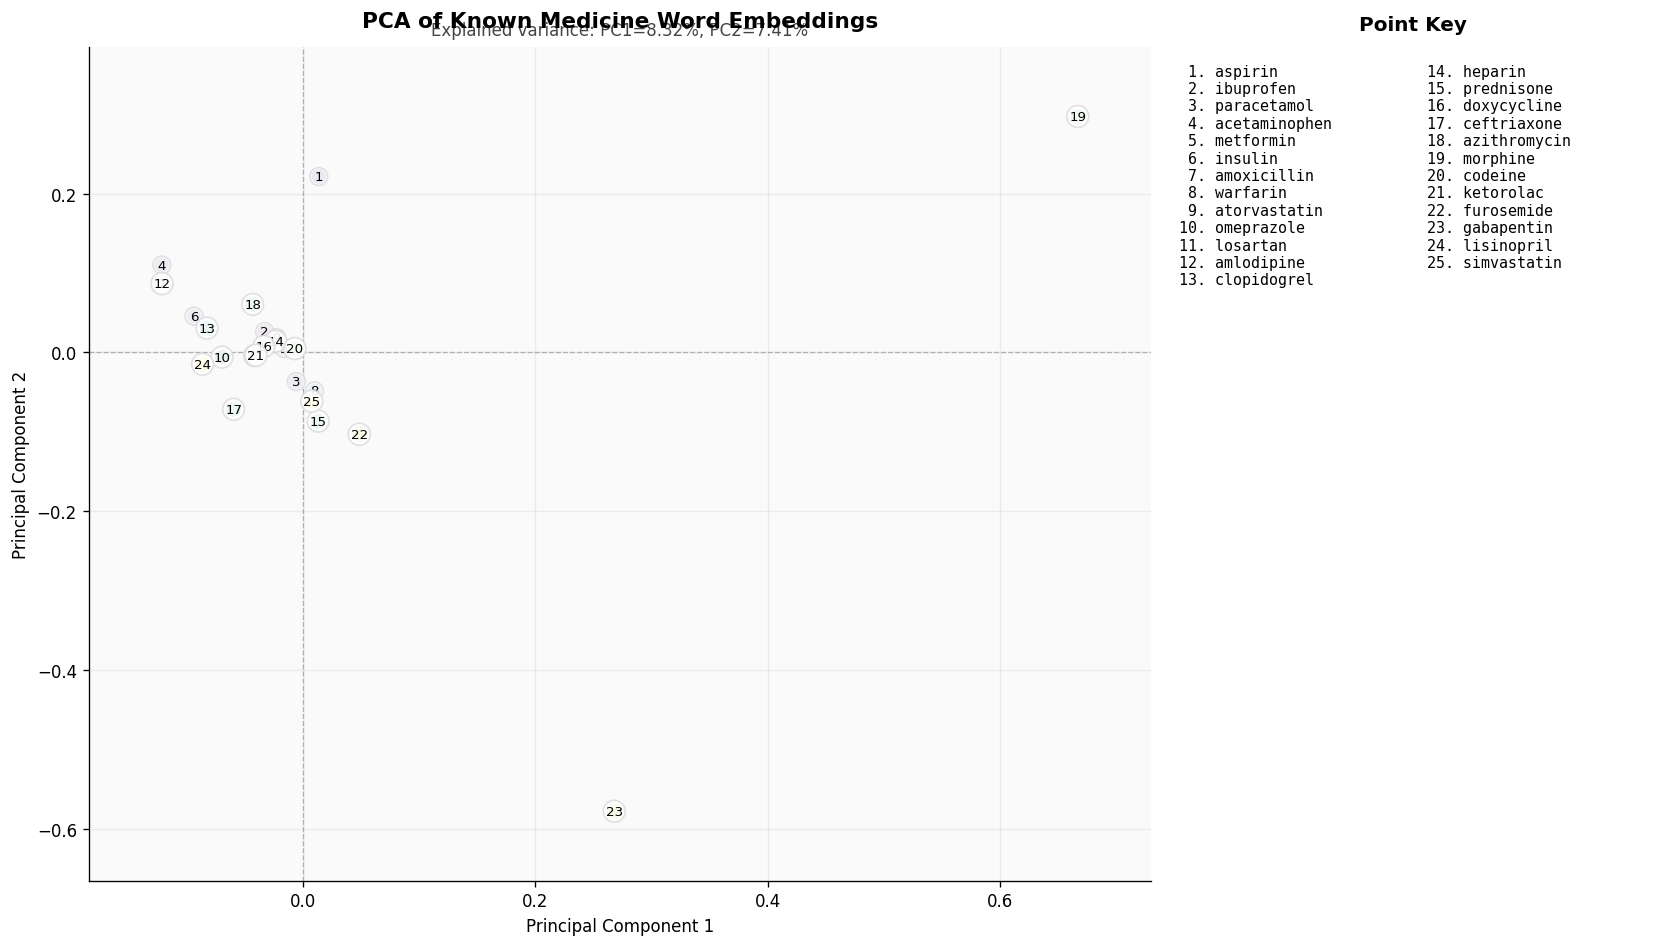

PCA explained variance ratio: [0.08322992 0.07409743]


In [30]:
# ## 5.1) PCA Plot of Known Medicine Word Embeddings
from typing import Any
from sklearn.decomposition import PCA

known_words = [
    "aspirin", "ibuprofen", "paracetamol", "acetaminophen", "metformin",
    "insulin", "amoxicillin", "warfarin", "atorvastatin", "omeprazole",
    "losartan", "amlodipine", "clopidogrel", "heparin", "prednisone",
    "doxycycline", "ceftriaxone", "azithromycin", "morphine", "codeine",
    "ketorolac", "furosemide", "gabapentin", "lisinopril", "simvastatin",
]

resolver_fn = globals().get("_get_active_inference_model")
active_model_for_vectors = resolver_fn() if callable(resolver_fn) else None
if active_model_for_vectors is None:
    if "trainer" in globals() and getattr(trainer, "model", None) is not None:
        active_model_for_vectors = trainer.model
    elif "model" in globals() and model is not None:
        active_model_for_vectors = model

if active_model_for_vectors is None:
    raise RuntimeError("Model is not available for PCA visualization. Run model setup/training cells first.")

active_model_any: Any = active_model_for_vectors
get_embeddings_fn = getattr(active_model_any, "get_input_embeddings", None)
if not callable(get_embeddings_fn):
    raise RuntimeError("Active model does not expose input embeddings for PCA visualization.")

embedding_layer: Any = get_embeddings_fn()
vectors = []
labels = []

for word in known_words:
    token_ids = tokenizer(word, add_special_tokens=False)["input_ids"]
    if not token_ids:
        continue
    first_token_id = int(token_ids[0])
    token_id_tensor = torch.tensor([first_token_id], device=embedding_layer.weight.device)
    token_vector = embedding_layer(token_id_tensor)[0].detach().float().cpu().numpy()
    vectors.append(token_vector)
    labels.append(word)

if len(vectors) < 20:
    raise RuntimeError(f"Only {len(vectors)} valid vectors were collected. Expected at least 20.")

vec_matrix = np.vstack(vectors)
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(vec_matrix)

pca_df = pd.DataFrame({
    "id": np.arange(1, len(labels) + 1),
    "word": labels,
    "pc1": coords[:, 0],
    "pc2": coords[:, 1],
})
display(pca_df[["id", "word", "pc1", "pc2"]])

evr = pca.explained_variance_ratio_
fig, (ax_scatter, ax_key) = plt.subplots(
    1, 2, figsize=(14, 8), dpi=120, gridspec_kw={"width_ratios": [2.4, 1.1]}
)
ax_scatter.set_facecolor("#fafafa")

color_values = np.linspace(0, 1, len(pca_df))
ax_scatter.scatter(
    pca_df["pc1"],
    pca_df["pc2"],
    c=color_values,
    cmap="viridis",
    s=95,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.9,
    zorder=2,
)

for _, row in pca_df.iterrows():
    ax_scatter.text(
        row["pc1"],
        row["pc2"],
        str(int(row["id"])),
        fontsize=8,
        ha="center",
        va="center",
        color="black",
        bbox={"boxstyle": "circle,pad=0.18", "fc": "white", "ec": "#dddddd", "alpha": 0.9},
        zorder=3,
    )

x_range = max(float(pca_df["pc1"].max() - pca_df["pc1"].min()), 1e-6)
y_range = max(float(pca_df["pc2"].max() - pca_df["pc2"].min()), 1e-6)
ax_scatter.set_xlim(float(pca_df["pc1"].min() - 0.08 * x_range), float(pca_df["pc1"].max() + 0.08 * x_range))
ax_scatter.set_ylim(float(pca_df["pc2"].min() - 0.1 * y_range), float(pca_df["pc2"].max() + 0.1 * y_range))
ax_scatter.axhline(0, color="#666", linestyle="--", linewidth=0.8, alpha=0.45)
ax_scatter.axvline(0, color="#666", linestyle="--", linewidth=0.8, alpha=0.45)
ax_scatter.set_title("PCA of Known Medicine Word Embeddings", fontsize=13, fontweight="bold", pad=12)
ax_scatter.text(
    0.5,
    1.01,
    f"Explained variance: PC1={evr[0]:.2%}, PC2={evr[1]:.2%}",
    transform=ax_scatter.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#444",
)
ax_scatter.set_xlabel("Principal Component 1")
ax_scatter.set_ylabel("Principal Component 2")
ax_scatter.grid(alpha=0.2)
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

# Clean key panel for number-to-word mapping
ax_key.axis("off")
ax_key.set_title("Point Key", fontsize=12, fontweight="bold", pad=10)

items = [f"{int(r.id):>2}. {r.word}" for r in pca_df.itertuples(index=False)]
split_idx = (len(items) + 1) // 2
left_items = items[:split_idx]
right_items = items[split_idx:]

left_text = "\n".join(left_items)
right_text = "\n".join(right_items)

ax_key.text(0.02, 0.98, left_text, va="top", ha="left", fontsize=9, family="monospace")
ax_key.text(0.53, 0.98, right_text, va="top", ha="left", fontsize=9, family="monospace")

fig.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {evr}")

In [18]:
# ## 5.2) Export Artifacts and Final Environment Snapshot
final_env_info = gpu_report()
with open(f"{LOG_DIR}/final_environment_report.json", "w", encoding="utf-8") as f:
    json.dump(final_env_info, f, indent=2)

artifact_manifest = {
    "timestamp": datetime.now().isoformat(),
    "output_dir": OUTPUT_DIR,
    "adapter_dir": ADAPTER_DIR,
    "artifacts": [
        f"{LOG_DIR}/environment_report.json",
        f"{LOG_DIR}/final_environment_report.json",
        f"{LOG_DIR}/trainer_log_history.csv",
        BASELINE_OUTPUT_PATH,
        AFTER_OUTPUT_PATH,
        TRAIN_REPORT_PATH,
    ],
}

with open(f"{OUTPUT_DIR}/artifact_manifest.json", "w", encoding="utf-8") as f:
    json.dump(artifact_manifest, f, indent=2)

print("Artifact manifest generated.")
print(json.dumps(artifact_manifest, indent=2))

Artifact manifest generated.
{
  "timestamp": "2026-04-24T23:12:12.134750",
  "output_dir": "./outputs_pharma_qlora",
  "adapter_dir": "./outputs_pharma_qlora/adapter",
  "artifacts": [
    "./outputs_pharma_qlora/logs/environment_report.json",
    "./outputs_pharma_qlora/logs/final_environment_report.json",
    "./outputs_pharma_qlora/logs/trainer_log_history.csv",
    "./outputs_pharma_qlora/baseline_generations.json",
    "./outputs_pharma_qlora/finetuned_generations.json",
    "./outputs_pharma_qlora/training_report.json"
  ]
}


## Local Deployment

In [32]:
# ## 6.1) Launch Optional Local Gradio Demo
import sys

try:
    import gradio as gr
except ImportError:
    gr = None
    print("gradio is not installed in this kernel. Run `%pip install gradio` in this notebook and rerun this cell.")

print(f"Notebook Python: {sys.executable}")
if gr is not None:
    print(f"Gradio version: {gr.__version__}")

def _get_active_inference_model():
    if "trainer" in globals() and getattr(trainer, "model", None) is not None:
        return trainer.model
    if "model" in globals() and model is not None:
        return model
    return None

if gr is not None:
    DEFAULT_DEMO_MEDICINE = "Metformin"
    DEFAULT_DEMO_SYSTEM_PROMPT = SYSTEM_PROMPT
    DEFAULT_DEMO_PROMPT_TEMPLATE = USER_PROMPT_TEMPLATE

    def local_demo_infer(
        drug_name,
        custom_system_prompt,
        custom_prompt_template,
        temperature,
        max_new_tokens,
    ):
        name = (drug_name or "").strip()
        if not name:
            return "Please enter a medicine name."

        active_model = _get_active_inference_model()
        if active_model is None or "generate_answer" not in globals():
            return "Model is not ready. Run model setup/training cells first, then retry."

        active_model.eval()
        return generate_answer(
            active_model,
            name,
            max_new_tokens=int(max_new_tokens),
            temperature=float(temperature),
            system_prompt=(custom_system_prompt or SYSTEM_PROMPT),
            user_prompt_template=(custom_prompt_template or USER_PROMPT_TEMPLATE),
        )

    demo = gr.Interface(
        fn=local_demo_infer,
        inputs=[
            gr.Textbox(label="Medicine name", value=DEFAULT_DEMO_MEDICINE),
            gr.Textbox(label="System prompt", value=DEFAULT_DEMO_SYSTEM_PROMPT, lines=4),
            gr.Textbox(label="User prompt template", value=DEFAULT_DEMO_PROMPT_TEMPLATE, lines=2),
            gr.Slider(label="Temperature", minimum=0.0, maximum=1.0, step=0.05, value=0.2),
            gr.Slider(label="Max new tokens", minimum=64, maximum=512, step=16, value=220),
        ],
        outputs=gr.Textbox(label="Model response", lines=12),
        title="Pharmacology Assistant (Local Notebook Demo)",
        description="Edit medicine name and prompts directly here for quick testing.",
    )

    LAUNCH_LOCAL_DEMO = True
    if LAUNCH_LOCAL_DEMO:
        demo.launch(share=False)
    else:
        print("Local demo is ready. Set LAUNCH_LOCAL_DEMO=True and rerun this cell to start it.")

Notebook Python: c:\Users\USER\Codes\.venv\Scripts\python.exe
Gradio version: 6.13.0
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


[transformers] Both `max_new_tokens` (=220) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
